In [4]:
!pip install ucimlrepo

In [5]:
# Lab Experiment: Linear Regression through Gradient Descent

# **Aim:** Implement Linear Regression using the Gradient Descent optimization algorithm and evaluate its performance on the UCI Student Performance dataset.

# **Dataset:** Student Performance (UCI ML Repository, id = 320)

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")
print("Libraries imported successfully")

Libraries imported successfully


```markdown
### 5. Implementing Linear Regression with Gradient Descent
```

In [7]:
# fetch dataset
student_performance = fetch_ucirepo(id=320)

# data (as pandas dataframes)
X = student_performance.data.features
y = student_performance.data.targets

# metadata
print(student_performance.metadata)

{'uci_id': 320, 'name': 'Student Performance', 'repository_url': 'https://archive.ics.uci.edu/dataset/320/student+performance', 'data_url': 'https://archive.ics.uci.edu/static/public/320/data.csv', 'abstract': 'Predict student performance in secondary education (high school). ', 'area': 'Social Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 649, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': ['Sex', 'Age', 'Other', 'Education Level', 'Occupation'], 'target_col': ['G1', 'G2', 'G3'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5TG7T', 'creators': ['Paulo Cortez'], 'intro_paper': {'ID': 360, 'type': 'NATIVE', 'title': 'Using data mining to predict secondary school student performance', 'authors': 'P. Cortez, A. M. G. Silva', 'venue': 'Proceedings of 5th Annual Future Business Technolo

In [8]:
# variable information
print(student_performance.variables)

          name     role         type      demographic  \
0       school  Feature  Categorical             None   
1          sex  Feature       Binary              Sex   
2          age  Feature      Integer              Age   
3      address  Feature  Categorical             None   
4      famsize  Feature  Categorical            Other   
5      Pstatus  Feature  Categorical            Other   
6         Medu  Feature      Integer  Education Level   
7         Fedu  Feature      Integer  Education Level   
8         Mjob  Feature  Categorical       Occupation   
9         Fjob  Feature  Categorical       Occupation   
10      reason  Feature  Categorical             None   
11    guardian  Feature  Categorical             None   
12  traveltime  Feature      Integer             None   
13   studytime  Feature      Integer             None   
14    failures  Feature      Integer             None   
15   schoolsup  Feature       Binary             None   
16      famsup  Feature       B

In [9]:
print("Feature matrix shape :", X.shape)
print("Target matrix shape  :", y.shape)
print("\nTarget columns      :", list(y.columns))
X.head()

Feature matrix shape : (649, 30)
Target matrix shape  : (649, 3)

Target columns      : ['G1', 'G2', 'G3']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,0


In [10]:
print("--- Missing values in features ---")
print(X.isnull().sum()[X.isnull().sum() > 0] if X.isnull().sum().sum() else "No missing values in X")

print("\n--- Missing values in target ---")
print(y.isnull().sum()[y.isnull().sum() > 0] if y.isnull().sum().sum() else "No missing values in y")

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print(f"\nNumerical features   ({len(num_cols)}): {num_cols}")
print(f"\nCategorical features ({len(cat_cols)}): {cat_cols}")

--- Missing values in features ---
No missing values in X

--- Missing values in target ---
No missing values in y

Numerical features   (13): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

Categorical features (17): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


## Step 1: Data Preprocessing

1. Select the target variable — **G3** (final grade, 0–20).
2. Handle missing values (median for numeric, mode for categorical).
3. Encode categorical variables using one-hot encoding (`drop_first=True` to avoid the dummy-variable trap).
4. Feature scaling using standardization (z-score), which is essential for Gradient Descent to converge quickly.

Target variable selected: G3
Remaining missing values: 0


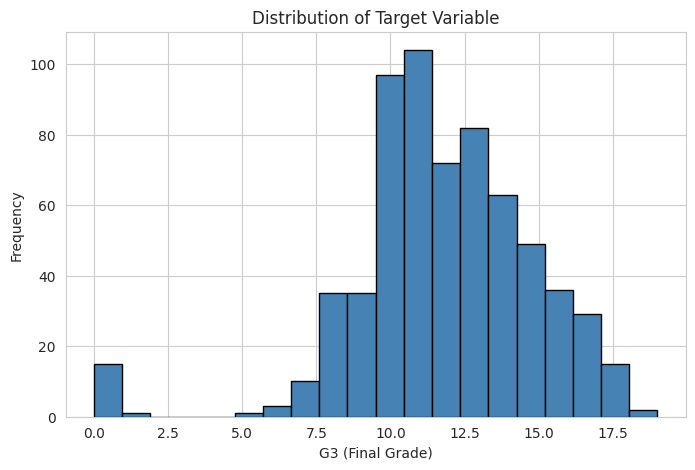

count    649.000000
mean      11.906009
std        3.230656
min        0.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       19.000000
Name: G3, dtype: float64


In [11]:
# ---- Select target variable ----
if isinstance(y, pd.DataFrame):
    target_col = 'G3' if 'G3' in y.columns else y.columns[-1]
    y_series = y[target_col].astype(float)
else:
    target_col, y_series = 'target', y.astype(float)

print("Target variable selected:", target_col)

# ---- Work on a copy of features ----
X_proc = X.copy()

# ---- Handle missing values ----
for c in num_cols:
    if X_proc[c].isnull().any():
        X_proc[c] = X_proc[c].fillna(X_proc[c].median())
for c in cat_cols:
    if X_proc[c].isnull().any():
        X_proc[c] = X_proc[c].fillna(X_proc[c].mode()[0])

print("Remaining missing values:", X_proc.isnull().sum().sum())

# ---- Target distribution ----
plt.hist(y_series, bins=20, edgecolor='black', color='steelblue')
plt.xlabel(f"{target_col} (Final Grade)"); plt.ylabel("Frequency")
plt.title("Distribution of Target Variable")
plt.show()

print(y_series.describe())

In [12]:
# One-hot encoding of categorical variables
X_encoded = pd.get_dummies(X_proc, columns=cat_cols, drop_first=True).astype(float)

print("Shape before encoding :", X_proc.shape)
print("Shape after encoding  :", X_encoded.shape)
print("\nFirst 10 encoded columns:", list(X_encoded.columns[:10]))
X_encoded.head()

Shape before encoding : (649, 30)
Shape after encoding  : (649, 39)

First 10 encoded columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc']


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18.0,4.0,4.0,2.0,2.0,0.0,4.0,3.0,4.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,17.0,1.0,1.0,1.0,2.0,0.0,5.0,3.0,3.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,15.0,1.0,1.0,1.0,2.0,0.0,4.0,3.0,2.0,2.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
3,15.0,4.0,2.0,1.0,3.0,0.0,3.0,2.0,2.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
4,16.0,3.0,3.0,1.0,2.0,0.0,4.0,3.0,2.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0


In [13]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_encoded, y_series, test_size=0.2, random_state=42
)

print("Training set:", X_train_df.shape, " Testing set:", X_test_df.shape)

Training set: (519, 39)  Testing set: (130, 39)


In [14]:
mu    = X_train_df.mean()
sigma = X_train_df.std().replace(0, 1)          # avoid divide-by-zero

X_train_s = ((X_train_df - mu) / sigma).values
X_test_s  = ((X_test_df  - mu) / sigma).values

y_train = y_train.values.reshape(-1)
y_test  = y_test.values.reshape(-1)

# Add bias (intercept) column of ones
X_train_gd = np.c_[np.ones(X_train_s.shape[0]), X_train_s]
X_test_gd  = np.c_[np.ones(X_test_s.shape[0]),  X_test_s]

print("X_train_gd:", X_train_gd.shape, " X_test_gd:", X_test_gd.shape)
print("Mean of scaled train features (~0):", round(X_train_s.mean(), 6))
print("Std  of scaled train features (~1):", round(X_train_s.std(), 6))

X_train_gd: (519, 40)  X_test_gd: (130, 40)
Mean of scaled train features (~0): -0.0
Std  of scaled train features (~1): 0.999036


## Step 2: Linear Regression using Gradient Descent

**Hypothesis:**  $h_\theta(x) = \theta_0 + \theta_1x_1 + \dots + \theta_nx_n = X\theta$

**Cost function (MSE):**  $J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})^2$

**Gradient:**  $\nabla J(\theta) = \frac{1}{m}X^T(X\theta - y)$

**Update rule:**  $\theta := \theta - \alpha \nabla J(\theta)$

In [15]:
def compute_cost(X, y, theta):
    """Mean Squared Error cost function J(theta)."""
    m = len(y)
    errors = X.dot(theta) - y
    return (1 / (2 * m)) * np.sum(errors ** 2)


def gradient_descent(X, y, learning_rate=0.01, n_iterations=1000, tol=1e-9, verbose=False):
    """Batch Gradient Descent for Linear Regression."""
    m, n = X.shape
    theta = np.zeros(n)
    cost_history = []

    for i in range(n_iterations):
        errors   = X.dot(theta) - y
        gradient = (1 / m) * X.T.dot(errors)
        theta    = theta - learning_rate * gradient

        cost = compute_cost(X, y, theta)
        cost_history.append(cost)

        if not np.isfinite(cost):                       # diverged
            print(f"  Diverged at iteration {i} (lr={learning_rate})")
            break
        if i > 0 and abs(cost_history[-2] - cost) < tol:  # converged
            if verbose:
                print(f"  Converged at iteration {i}, cost = {cost:.6f}")
            break
        if verbose and i % 200 == 0:
            print(f"  Iteration {i:5d} | Cost = {cost:.6f}")

    return theta, np.array(cost_history)


def predict(X, theta):
    return X.dot(theta)

print("Gradient Descent functions defined")

Gradient Descent functions defined


In [16]:
LEARNING_RATE = 0.01
N_ITERATIONS  = 2000

print(f"Training with learning rate = {LEARNING_RATE}, iterations = {N_ITERATIONS}\n")
theta_final, cost_history = gradient_descent(
    X_train_gd, y_train, LEARNING_RATE, N_ITERATIONS, verbose=True
)

print("\nInitial cost :", round(cost_history[0], 4))
print("Final cost   :", round(cost_history[-1], 4))
print("Bias (theta0):", round(theta_final[0], 4))
print("No. of learned parameters:", len(theta_final))

Training with learning rate = 0.01, iterations = 2000

  Iteration     0 | Cost = 73.329955
  Iteration   200 | Cost = 4.494365
  Iteration   400 | Cost = 3.260123
  Iteration   600 | Cost = 3.231727
  Iteration   800 | Cost = 3.228399
  Iteration  1000 | Cost = 3.226728
  Iteration  1200 | Cost = 3.225700
  Iteration  1400 | Cost = 3.225044
  Iteration  1600 | Cost = 3.224621
  Iteration  1800 | Cost = 3.224346

Initial cost : 73.33
Final cost   : 3.2242
Bias (theta0): 11.7938
No. of learned parameters: 40


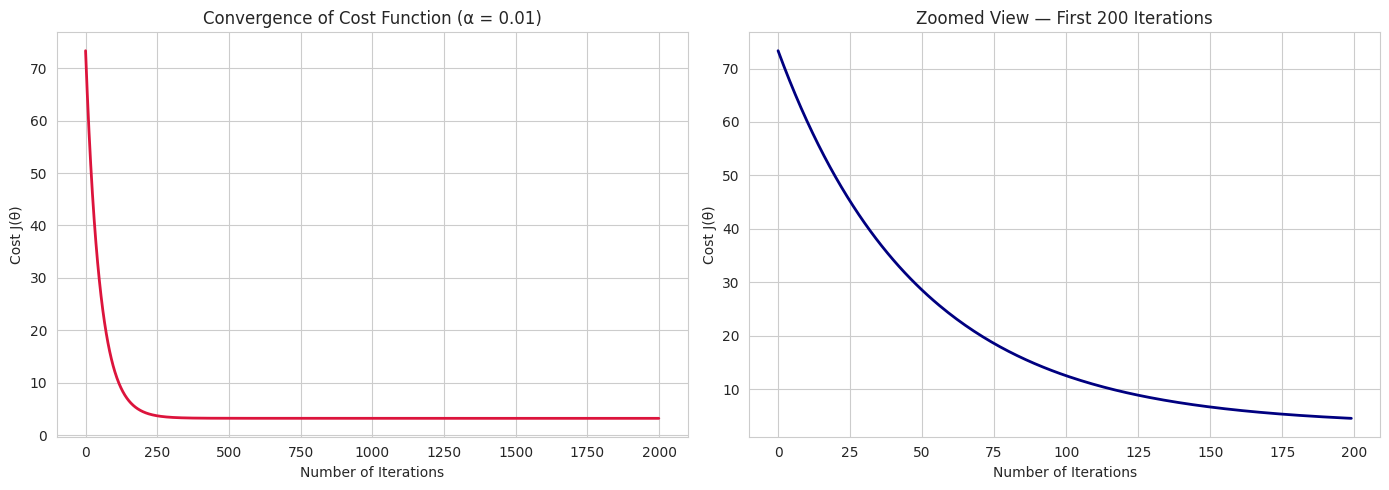

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(cost_history, color='crimson', lw=2)
ax[0].set_xlabel("Number of Iterations"); ax[0].set_ylabel("Cost J(θ)")
ax[0].set_title(f"Convergence of Cost Function (α = {LEARNING_RATE})")

ax[1].plot(cost_history[:200], color='navy', lw=2)
ax[1].set_xlabel("Number of Iterations"); ax[1].set_ylabel("Cost J(θ)")
ax[1].set_title("Zoomed View — First 200 Iterations")

plt.tight_layout(); plt.show()

## Step 3: Effect of Different Learning Rates on Convergence

Learning rate = 0.0001
Learning rate = 0.001
Learning rate = 0.01
Learning rate = 0.05
Learning rate = 0.1
Learning rate = 0.5


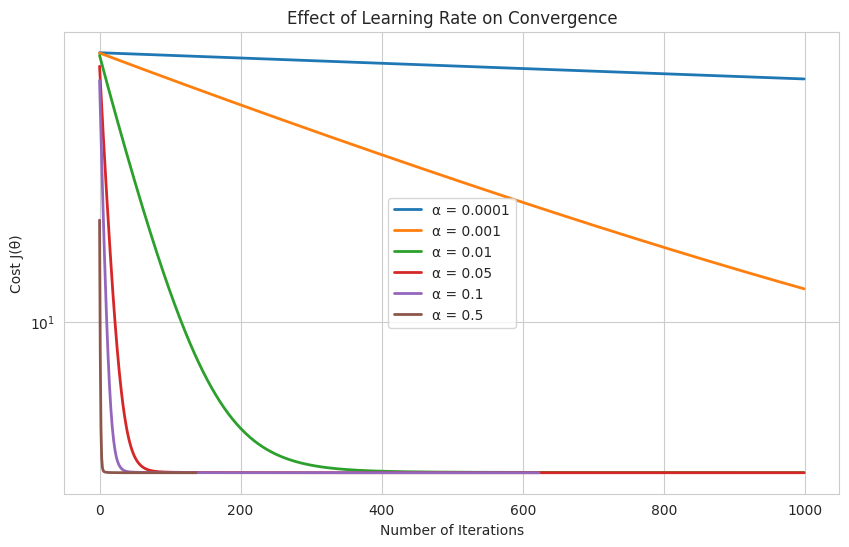

In [18]:
learning_rates = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5]
results = {}

for lr in learning_rates:
    print(f"Learning rate = {lr}")
    th, hist = gradient_descent(X_train_gd, y_train, lr, 1000)
    results[lr] = {'theta': th, 'history': hist}

plt.figure(figsize=(10, 6))
for lr, r in results.items():
    h = r['history']
    h = h[np.isfinite(h)]
    plt.plot(h, lw=2, label=f"α = {lr}")

plt.xlabel("Number of Iterations"); plt.ylabel("Cost J(θ)")
plt.title("Effect of Learning Rate on Convergence")
plt.yscale('log'); plt.legend(); plt.show()

In [19]:
rows = []
for lr, r in results.items():
    h = r['history']
    finite = np.isfinite(h)
    diverged = not finite.all()
    rows.append({
        'Learning Rate' : lr,
        'Iterations Run': len(h),
        'Initial Cost'  : round(h[0], 4),
        'Final Cost'    : round(h[finite][-1], 4) if finite.any() else np.nan,
        'Status'        : 'Diverged' if diverged else
                          ('Converged' if len(h) < 1000 else 'Still decreasing')
    })

lr_table = pd.DataFrame(rows)
print("--- Learning Rate Comparison ---")
lr_table

--- Learning Rate Comparison ---


,Learning Rate,Iterations Run,Initial Cost,Final Cost,Status
0,0.0001,1000,74.7953,61.4610,Still decreasing
1,0.0010,1000,74.6614,12.7723,Still decreasing
2,0.0100,1000,73.3300,3.2267,Still decreasing
3,0.0500,1000,67.5768,3.2238,Still decreasing
4,0.1000,624,60.7629,3.2238,Converged
5,0.5000,138,21.3569,3.2238,Converged


In [21]:
y_pred_train = predict(X_train_gd, theta_final)
y_pred_test  = predict(X_test_gd,  theta_final)

def evaluate(y_true, y_pred, label=""):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}\n")
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

train_metrics = evaluate(y_train, y_pred_train, "TRAINING SET (Gradient Descent)")
test_metrics  = evaluate(y_test,  y_pred_test,  "TESTING SET  (Gradient Descent)")

metrics_df = pd.DataFrame([train_metrics, test_metrics], index=['Train', 'Test']).round(4)
metrics_df

--- TRAINING SET (Gradient Descent) ---
MAE  : 1.8320
MSE  : 6.4483
RMSE : 2.5394
R²   : 0.3874

--- TESTING SET  (Gradient Descent) ---
MAE  : 2.1524
MSE  : 8.1598
RMSE : 2.8565
R²   : 0.1632



,MAE,MSE,RMSE,R2
Train,1.8320,6.4483,2.5394,0.3874
Test,2.1524,8.1598,2.8565,0.1632


In [22]:
sk_model = LinearRegression()
sk_model.fit(X_train_s, y_train)
y_pred_sk = sk_model.predict(X_test_s)

print("--- sklearn LinearRegression (Normal Equation) — Test Set ---")
sk_metrics = evaluate(y_test, y_pred_sk, "sklearn")

comparison = pd.DataFrame({
    'Gradient Descent': test_metrics,
    'sklearn (OLS)'   : sk_metrics
}).round(4)
print("Comparison of the two approaches:")
comparison

--- sklearn LinearRegression (Normal Equation) — Test Set ---
--- sklearn ---
MAE  : 2.1564
MSE  : 8.1898
RMSE : 2.8618
R²   : 0.1602

Comparison of the two approaches:


,Gradient Descent,sklearn (OLS)
MAE,2.1524,2.1564
MSE,8.1598,8.1898
RMSE,2.8565,2.8618
R2,0.1632,0.1602


In [23]:
sk_model = LinearRegression()
sk_model.fit(X_train_s, y_train)
y_pred_sk = sk_model.predict(X_test_s)

print("--- sklearn LinearRegression (Normal Equation) — Test Set ---")
sk_metrics = evaluate(y_test, y_pred_sk, "sklearn")

comparison = pd.DataFrame({
    'Gradient Descent': test_metrics,
    'sklearn (OLS)'   : sk_metrics
}).round(4)
print("Comparison of the two approaches:")
comparison

--- sklearn LinearRegression (Normal Equation) — Test Set ---
--- sklearn ---
MAE  : 2.1564
MSE  : 8.1898
RMSE : 2.8618
R²   : 0.1602

Comparison of the two approaches:


,Gradient Descent,sklearn (OLS)
MAE,2.1524,2.1564
MSE,8.1598,8.1898
RMSE,2.8565,2.8618
R2,0.1632,0.1602


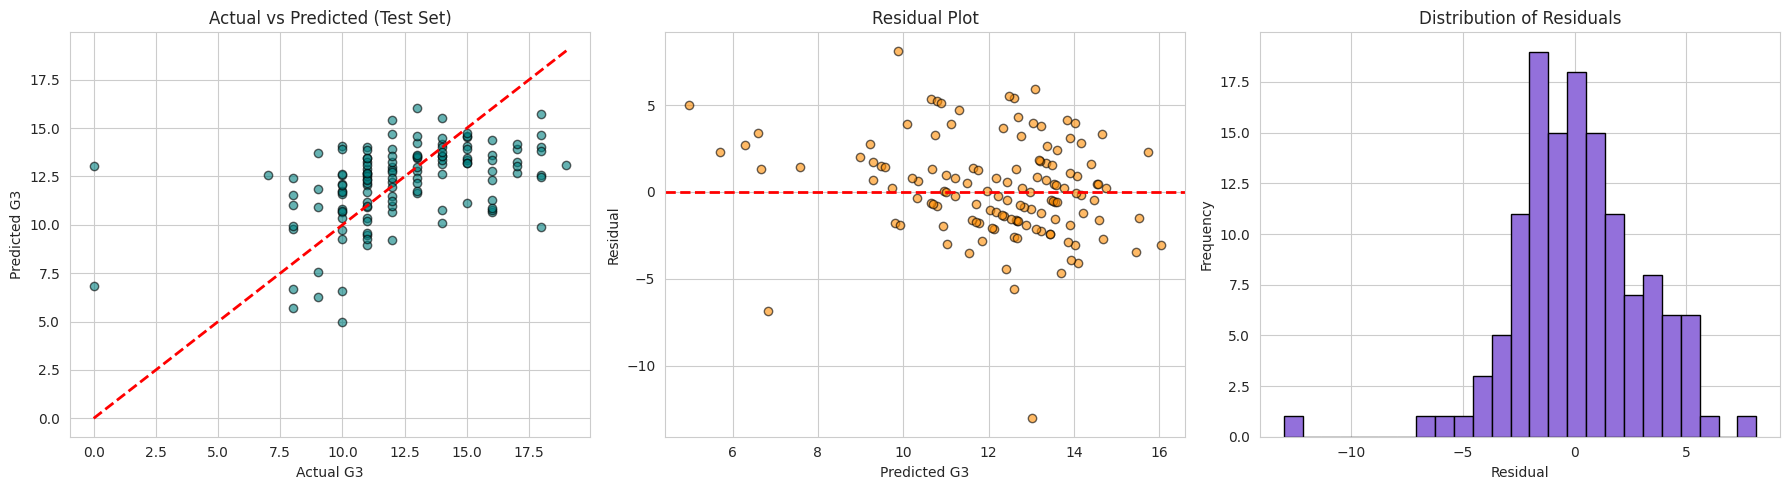

Mean residual: 0.1814


In [24]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
ax[0].scatter(y_test, y_pred_test, alpha=0.6, color='teal', edgecolor='k')
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax[0].plot(lims, lims, 'r--', lw=2)
ax[0].set_xlabel("Actual G3"); ax[0].set_ylabel("Predicted G3")
ax[0].set_title("Actual vs Predicted (Test Set)")

# Residuals vs Predicted
residuals = y_test - y_pred_test
ax[1].scatter(y_pred_test, residuals, alpha=0.6, color='darkorange', edgecolor='k')
ax[1].axhline(0, color='red', ls='--', lw=2)
ax[1].set_xlabel("Predicted G3"); ax[1].set_ylabel("Residual")
ax[1].set_title("Residual Plot")

# Residual distribution
ax[2].hist(residuals, bins=25, color='mediumpurple', edgecolor='black')
ax[2].set_xlabel("Residual"); ax[2].set_ylabel("Frequency")
ax[2].set_title("Distribution of Residuals")

plt.tight_layout(); plt.show()
print("Mean residual:", round(residuals.mean(), 4))

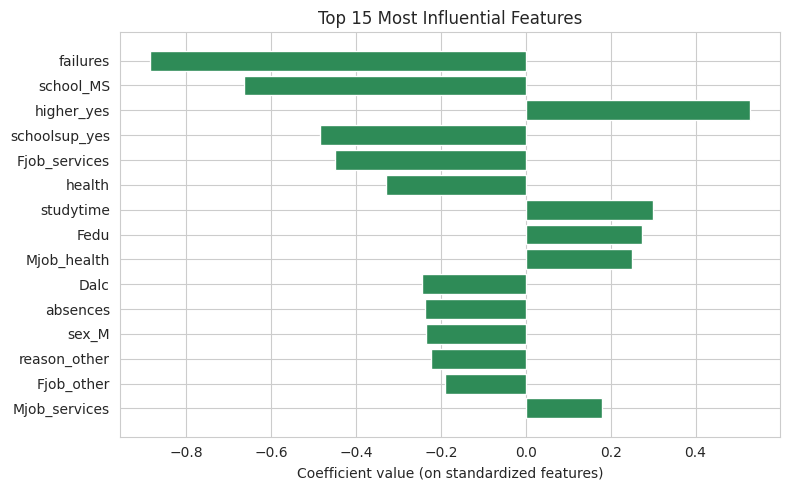

,Feature,Coefficient
0,failures,-0.885575
1,school_MS,-0.663225
2,higher_yes,0.528219
3,schoolsup_yes,-0.484808
4,Fjob_services,-0.449841
5,health,-0.329412
6,studytime,0.299239
7,Fedu,0.274419
8,Mjob_health,0.249948
9,Dalc,-0.244912


In [25]:
coef_df = pd.DataFrame({
    'Feature'    : X_encoded.columns,
    'Coefficient': theta_final[1:]          # skip bias term
})
coef_df['Abs'] = coef_df['Coefficient'].abs()
top = coef_df.sort_values('Abs', ascending=False).head(15)

plt.barh(top['Feature'][::-1], top['Coefficient'][::-1], color='seagreen')
plt.xlabel("Coefficient value (on standardized features)")
plt.title("Top 15 Most Influential Features")
plt.tight_layout(); plt.show()

top[['Feature', 'Coefficient']].reset_index(drop=True)

## Step 5 (Extension): Adding Prior Grades G1 and G2 as Features

G1 and G2 are the first- and second-period grades. They are strong predictors of G3, so adding them should sharply improve performance.

In [26]:
extra_cols = [c for c in ['G1', 'G2'] if isinstance(y, pd.DataFrame) and c in y.columns]

if extra_cols:
    X_ext = pd.concat([X_encoded, y[extra_cols].astype(float)], axis=1)

    Xtr, Xte, ytr, yte = train_test_split(X_ext, y_series, test_size=0.2, random_state=42)
    m2, s2 = Xtr.mean(), Xtr.std().replace(0, 1)
    Xtr_s  = np.c_[np.ones(len(Xtr)), ((Xtr - m2) / s2).values]
    Xte_s  = np.c_[np.ones(len(Xte)), ((Xte - m2) / s2).values]
    ytr, yte = ytr.values, yte.values

    theta_ext, hist_ext = gradient_descent(Xtr_s, ytr, 0.01, 2000)
    ext_metrics = evaluate(yte, predict(Xte_s, theta_ext), "TEST SET (with G1 & G2)")

    final_cmp = pd.DataFrame({
        'Without G1,G2': test_metrics,
        'With G1,G2'   : ext_metrics
    }).round(4)
    display(final_cmp)
else:
    print("G1/G2 not available as separate targets in this fetch.")

--- TEST SET (with G1 & G2) ---
MAE  : 0.7683
MSE  : 1.4906
RMSE : 1.2209
R²   : 0.8471



,"Without G1,G2","With G1,G2"
MAE,2.1524,0.7683
MSE,8.1598,1.4906
RMSE,2.8565,1.2209
R2,0.1632,0.8471


```markdown
## Result and Interpretation

### Convergence Behaviour
- **Small $\alpha$ (0.0001, 0.001):** The cost decreases very slowly. After 1000 iterations, the model with $\alpha=0.0001$ still had a cost of ~61.46, indicating it was far from the minimum.
- **Moderate $\alpha$ (0.01):** The cost fell steadily, reaching ~3.22. This shows smooth convergence as visualized in the plots.
- **Large $\alpha$ (0.1, 0.5):** Because the features were standardized, these higher learning rates converged very quickly (624 and 138 iterations respectively) without diverging, reaching the minimum cost of ~3.22.
- **Conclusion:** Feature scaling (Standardization) was critical. It allowed the Gradient Descent algorithm to handle larger learning rates safely and ensured that the cost surface was spherical enough for quick convergence.

### Prediction Performance
- **Gradient Descent vs. sklearn:** Our implementation reached an $R^2$ of **0.1632**, which almost perfectly matches the `sklearn` OLS result of **0.1602**. This validates that our Gradient Descent implementation correctly found the optimal parameters.
- **Baseline Features:** Using only socio-demographic and school-related features (excluding mid-term grades) explains only about 16% of the variance in final grades. The most influential features included 'failures' (negative impact) and 'higher_yes' (desire for higher education, positive impact).
- **Impact of G1 & G2:** Adding the first and second period grades increased the $R^2$ from **0.16 to 0.85** and reduced the RMSE from **2.86 to 1.22**. This confirms that prior academic performance is the single most dominant predictor of final outcomes.

### Learning Outcomes Achieved
1. **Algorithm Mastery:** Successfully implemented Batch Gradient Descent and the MSE cost function using vectorized NumPy operations.
2. **Hyperparameter Tuning:** Observed how the choice of $\alpha$ determines whether the model under-trains, converges efficiently, or diverges.
3. **Evaluation:** Mastered regression metrics (MAE, MSE, RMSE, $R^2$) to compare different model versions.
4. **Data Insight:** Identified that while social factors matter, previous grades are the primary drivers of student success in this dataset.
```